# Granite based on global behavior (sensitivity and risk) for Bike Rental Predictions

This notebook leverages GRANITE to yield regional explanations on the BikeSharing dataset using global behavior based on sensitivity and risk. We first look at minimizing disagreement due to interactions (pure vs. full) and then to minimize disagreement due to distributional influence (marginal vs. conditional)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import root_mean_squared_error
from joblib import dump, load

# Local imports
from granite.data import get_data_bike
from granite.decompositions import get_components_brute_force, get_regional_decompositions
import numpy as np
import matplotlib.pyplot as plt

from granite.features import Features
from granite.fd_trees import FDTree
from granite.plots import bar, overlay_bars
from granite.decompositions import get_components_brute_force, get_regional_decompositions

/Users/max/miniconda3/envs/GRANITE/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Input Features

The BikeSharing dataset aims to predict the hourly count of bike rentals between years 2011
and 2012 in Washington state, based on time and weather features. It involves 17K instances
and 10 features.

First load the data and a `Features` object that stores information about the various features. 
Note that the data **X** must **always** be a numerical numpy array. Categorical features are assumed 
to have been ordinally encoded.

In [2]:
# Built-in function for the BikeSharing dataset
X, y, features = get_data_bike()
# Make months and weekdays smaller for the plots (optional)
features.feature_objs[1].cats = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
features.feature_objs[4].cats = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
features.summary()
cat_features = [0, 1, 3, 4, 5, 6]

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | yr                 | ordinal            | 2          | [0]              |
| 1 | mnth               | ordinal            | 12         | [1]              |
| 2 | hr                 | num_int            | 24         | [2]              |
| 3 | holiday            | bool               | 2          | [3]              |
| 4 | weekday            | ordinal            | 7          | [4]              |
| 5 | workingday         | bool               | 2          | [5]              |
| 6 | weathersit         | num_int            | 4          | [6]              |
| 7 | temp               | num                | inf        | [7]              |
| 8 | hum                | num                | inf        | [8]              |
| 9 | windspeed          | num                | inf        | [9]              |
----------------------------------------

This dataset involves 10 features of various types. The following Table can help understand their meaning and domain.

<p align="center">
    <img src="./Images/Features_bike.png" width="600">
</p>

### Fitting the model
Having fetched the data, we fit a `HistGradientBoostingRegressor`.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = HistGradientBoostingRegressor(random_state=0)

**Do not run the following cells if you have already trained the model. Skip to later cells.**

In [4]:
grid = {"learning_rate": np.logspace(-2, 0, 10),
        "max_depth" : [3, 4, 5, 6, 7],
        "max_iter" : [50, 100, 150, 200],
        'min_samples_leaf' : [1, 20, 40, 60, 80, 100]}

search = RandomizedSearchCV(
    model,
    cv=KFold(),
    scoring='neg_root_mean_squared_error',
    param_distributions=grid,
    verbose=2,
    n_iter=20,
    random_state=42
)
search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.5s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.2s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.3s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.3s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.2s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.1s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.1s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.1s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.1s
[CV] END learning_rate=0.3593813

,estimator,HistGradientB...andom_state=0)
,param_distributions,"{'learning_rate': array([0.01 ..., 1. ]), 'max_depth': [3, 4, ...], 'max_iter': [50, 100, ...], 'min_samples_leaf': [1, 20, ...]}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [5]:
# Recover the optimal CV model
model = search.best_estimator_
res = search.cv_results_
cv_perf = np.nan_to_num(-res['mean_test_score'], nan=1e10)
best_idx = np.argmin(cv_perf)

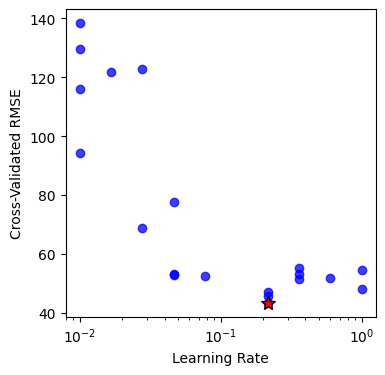

In [6]:
plt.figure(figsize=(4, 4))
plt.scatter(res['param_learning_rate'], cv_perf, c='b', alpha=0.75)
plt.plot(res['param_learning_rate'][best_idx], cv_perf[best_idx], 'r*', markersize=10, markeredgecolor='k')
plt.xlabel("Learning Rate")
plt.ylabel("Cross-Validated RMSE")
plt.xscale('log')
plt.show()

In [7]:
# Pickle the model
dump(model, os.path.join("models", "bike_gbt.joblib"))

['models/bike_gbt.joblib']

In [8]:
from granite.decompositions import get_components_tree
# Compute the H^k matrices using a subset of 1000 training points
background = X_test[:1000]
#decomposition = get_components_brute_force(model, background, background, features=features, anchored=True)
decomposition = get_components_tree(model, background, background, features=features, anchored=True)

[###########################################       ] 87%

#######] 100%

## Pure and Full Sobol Effects (Global Sensitivity Marginal)

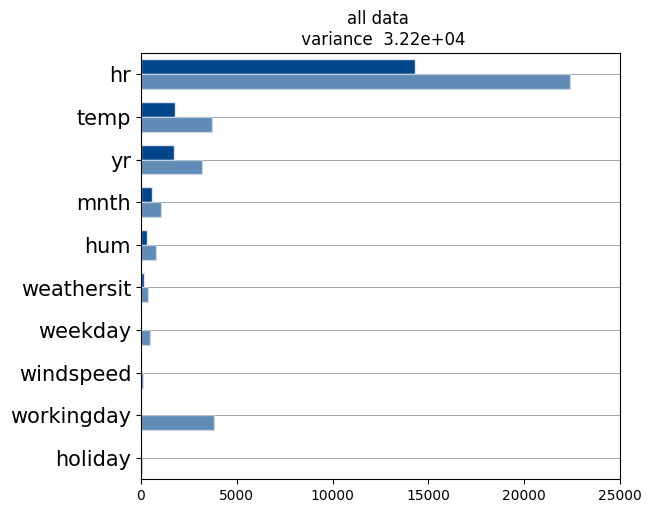

In [9]:
from granite.experiments import get_closed_total_sobol

H_tensor = np.stack([decomposition[(i,)] for i in range(len(features))], axis=-1)
closed_sobol_all_data, total_sobol_all_data = get_closed_total_sobol(H_tensor)
bar([closed_sobol_all_data, total_sobol_all_data], features.names())
plt.xlim(0, 25000)
plt.title(f"all data \n variance {decomposition[()].var(): .2e}")
# Save plot
plt.savefig(f"../figures/bike_sensitivity_pure_full_global.pdf", bbox_inches="tight")
plt.show()

**We minimize interactions between Total and closed Sobol indices (full and pure global sensitivity measure). Splits are similar to local effects.**

In [10]:
from granite.experiments import get_marginal_pure_vs_full_variance_loss_fn

marginal_pure_vs_full_loss_fn = get_marginal_pure_vs_full_variance_loss_fn(
                                        decomposition=decomposition,
                                        U=[(i,) for i in range(len(features))]
                                )

tree = FDTree(features, max_depth=2, save_losses=True, branching_per_node=3)
tree.fit(background, loss_fn=marginal_pure_vs_full_loss_fn)
tree.print(verbose=True)


Loss 1.0000
Samples 1000
If workingday ≤ 0.0000:
|   Loss 0.2345
|   Samples 341
|   If hr ≤ 7.0000:
|   |   Loss 0.0018
|   |   Samples 115
|   |   Region 0
|   else:
|   |   Loss 0.1021
|   |   Samples 226
|   |   Region 1
else:
|   Loss 0.2515
|   Samples 659
|   If hr ≤ 6.0000:
|   |   Loss 0.0003
|   |   Samples 189
|   |   Region 2
|   else:
|   |   Loss 0.1922
|   |   Samples 470
|   |   Region 3
Final Loss 0.2964


In [11]:
# Plot the loss function as a function of split candidate
plt.figure()
for i in range(len(features)):
    splits = tree.root.splits[i]
    objectives = tree.root.objectives[i]
    plt.plot(splits, objectives, '-o', label=i)
plt.xlabel("Split threshold")
plt.legend()

In [12]:
# Use the tree to compute regional decompositions
larger_background = X_test
regions = tree.predict(larger_background)
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
print(rules)
_, counts = np.unique(regions, return_counts=True)
print(counts)

[2 2 3 1 2 3 1 2 2 3]
{0: '(not workingday & hr<=7.00)', 1: '(not workingday & hr>7.00)', 2: '(workingday & hr<=6.00)', 3: '(workingday & hr>6.00)'}
[ 396  725  690 1665]


In [13]:
#regional_decompositions = get_regional_decompositions(decomposition, regions, regions, n_regions)
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions == r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_tree(model,
                                                    regional_backgrounds[r],
                                                    regional_backgrounds[r],
                                                    features,
                                                    anchored=True
                                                    )

[##################################################] 100%[                                                  ] 1%

##################################################] 100%[#                                                 ] 3%

#################################################] 100%[                                                  ] 0%

################################################  ] 97%

##] 100%

In [14]:
bar_plot_data = []
for r in range(tree.n_regions):
    H_tensor = np.stack([regional_decomposition[r][(i,)] for i in range(len(features))], axis=-1)
    closed_sobol, total_sobol = get_closed_total_sobol(H_tensor)
    bar_plot_data.append({"closed_sobol": closed_sobol, "total_sobol": total_sobol})
    bar([total_sobol, closed_sobol], features.names())
    plt.xlim(0, 25000)
    plt.title(f"{rules[r]} \n variance : {regional_decomposition[r][()].var():.2e} \n samples: {counts[r]} / {len(larger_background)}")
    # Save plot
    plt.savefig(f"../figures/bike_sensitivity_full_pure_region_{r}.pdf", bbox_inches="tight")
    plt.close()

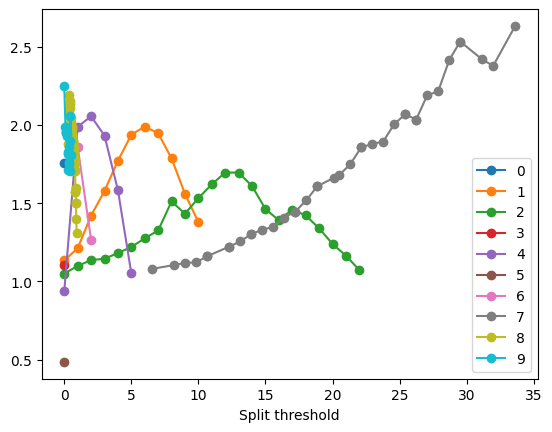

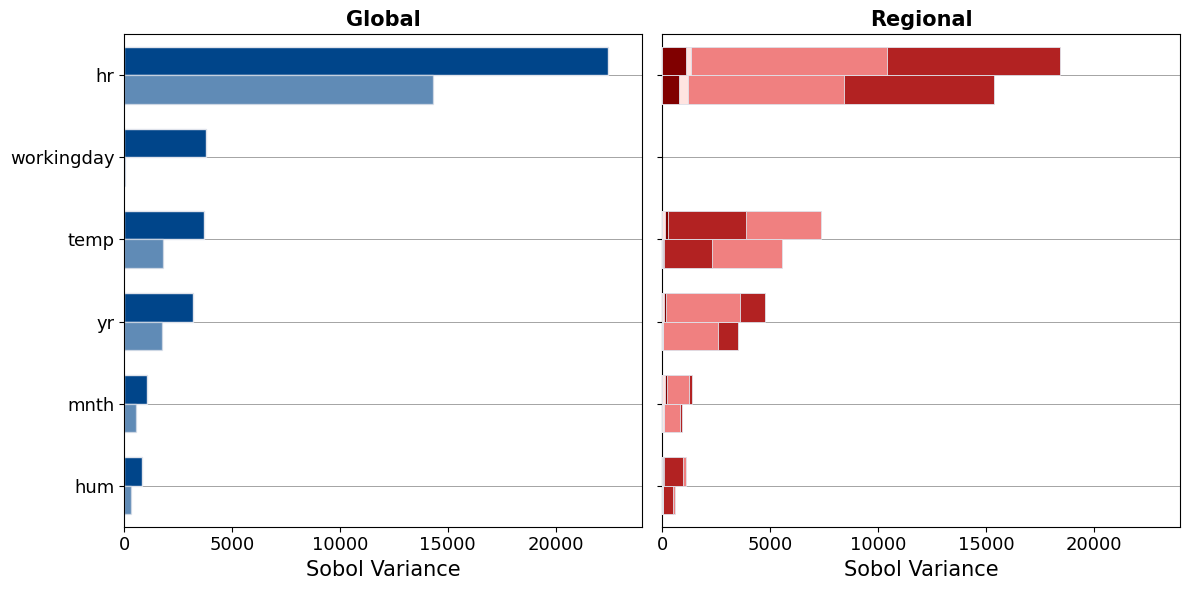

In [15]:
# plot both together
fig, (ax1, ax2) = plt.subplots(
    1, 2,                     # 1 row, 2 columns
    sharey=True,              # share y-axis for alignment
    figsize=(12, 6)           # width=12 inches, height=6 inches
)

order_features = list(reversed([2, 5, 7, 0, 1, 8]))

# left plot
bar([total_sobol_all_data, closed_sobol_all_data], features.names(), ax=ax1, ordered_features=order_features)

# right plot
overlay_bars(
    bar_plot_data,
    features.names(),
    metric_names=["total_sobol", "closed_sobol"],
    ax=ax2,
    region_colors=['maroon', 'lightcoral', 'mistyrose', 'firebrick'],
    ordered_features=order_features,
    legend_kwargs={"loc": "lower right", "frameon": True, "title": "$\\bf{Regions}$", "fontsize": 14},
    region_labels=[f"{rules[r]}".replace("(", "").replace(")", "") for r in range(tree.n_regions)],
    add_legend=False
)

# adjust plots
fontsize = 15
for ax in [ax1, ax2]:
    ax.set_xlim(0, 24000)
    ax.set_xlabel("Sobol Variance", fontsize=fontsize)
    ax.tick_params(axis="both", which="major", labelsize=fontsize - 2)
ax1.set_title("Global", weight="bold", fontsize=fontsize)
ax2.set_title("Regional", weight="bold", fontsize=fontsize)


plt.tight_layout()
plt.savefig("../figures/bike_sensitivity_stacked.pdf", bbox_inches="tight")
plt.show()


## Pure vs. Full PFI (Global Risk Marginal)

In [16]:
from granite.utils import decomposition_to_R, pointwise_squared_risk
from granite.experiments import get_pure_full_risk_effects

background = X_test[:2000]
decomposition = get_components_tree(model, background, background, features=features, anchored=True)
n_features = len(features)
R = decomposition_to_R(decomposition)
R = np.stack([R[(i,)] for i in range(n_features)], axis=-1)
risk_fn = pointwise_squared_risk
predictions = decomposition[()]
y_labels = y_test[:2000]
pure_risk, full_risk = get_pure_full_risk_effects(
    R, predictions, y_labels, risk_fn
)


[##################################################] 100%

In [17]:
# nu(D) - nu(empty)
risk_gap = risk_fn(predictions, y_labels).mean() - risk_fn(np.ones(2000)*predictions.mean(), y_labels).mean()
bar([full_risk.mean(0), pure_risk.mean(0)], features.names())
plt.title(f"all data \n risk gap {risk_gap: .2e}")
plt.xlim(0, 40000)
plt.savefig(f"../figures/bike_risk_full_pure_global.pdf", bbox_inches="tight")

In [18]:
from granite.experiments import get_marginal_pure_vs_full_risk_loss_fn

marginal_pure_vs_full_loss_fn = get_marginal_pure_vs_full_risk_loss_fn(
                                        decomposition=decomposition,
                                        U=[(i,) for i in range(n_features)],
                                        y=y_labels,
                                        risk_fn=pointwise_squared_risk
                                )

tree = FDTree(features, max_depth=2, save_losses=True, branching_per_node=3)
tree.fit(background, loss_fn=marginal_pure_vs_full_loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 2000
If yr ≤ 0.0000:
|   Loss 0.1343
|   Samples 1001
|   Region 0
else:
|   Loss 0.6640
|   Samples 999
|   If workingday ≤ 0.0000:
|   |   Loss 0.1603
|   |   Samples 324
|   |   Region 1
|   else:
|   |   Loss 0.3032
|   |   Samples 675
|   |   Region 2
Final Loss 0.5979


In [19]:
# Use the tree to compute regional decompositions
larger_background = X_test
y_background = y_test
regions = tree.predict(larger_background)
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
print(rules)
_, counts = np.unique(regions, return_counts=True)
print(counts)

#regional_decompositions = get_regional_decompositions(decomposition, regions, regions, n_regions)
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
regional_y = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions == r]
    regional_y[r] = y_background[regions == r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_tree(model,
                                                    regional_backgrounds[r],
                                                    regional_backgrounds[r],
                                                    features,
                                                    anchored=True
                                                    )

[0 2 0 0 2 0 1 0 0 2]
{0: 'yr=2011', 1: '(yr=2012 & not workingday)', 2: '(yr=2012 & workingday)'}
[1714  565 1197]


[##################################################] 100%[                                                  ] 0%

##################################################] 100%[                                                  ] 0%

##############################################    ] 92%

#####] 100%

In [20]:
for r in range(tree.n_regions):
    R = decomposition_to_R(regional_decomposition[r])
    R = np.stack([R[(i,)] for i in range(n_features)], axis=-1)
    risk_fn = pointwise_squared_risk
    predictions = regional_decomposition[r][()]
    y_labels = regional_y[r]
    # nu(D) - nu(empty)
    risk_gap = risk_fn(predictions, y_labels).mean() - risk_fn(np.ones(counts[r])*predictions.mean(), y_labels).mean()
    pure_risk, full_risk = get_pure_full_risk_effects(
        R, predictions, y_labels, risk_fn
    )
    bar([full_risk.mean(0), pure_risk.mean(0)], features.names())
    plt.title(f"{rules[r]} \n risk gap : {risk_gap:.2e} \n samples : {counts[r]} / {len(larger_background)}")
    plt.xlim(0, 40000)
    plt.savefig(f"../figures/bike_risk_full_pure_region_{r}.pdf", bbox_inches="tight")

**We calculate SAGE globally and within the regions found by minimizing interactions between full and pure global risk (PFI)**

In [21]:
# setup what you want to explain
from shapiq import InteractionValues, stacked_bar_plot

index = "k-SII"
order = 2

rules[-1] = "Whole Data"

In [22]:
# prepare and collect the data for shapiq
n_features = len(features)
n_samples_local = 100

x_explain_regions: dict[int, np.ndarray] = {}
data_regions: dict[int, np.ndarray] = {}
y_regions: dict[int, np.ndarray] = {}
for r in range(tree.n_regions):
    data_region = larger_background[regions==r]
    y_region = y_background[regions == r]
    x_explain_regions[r] = data_region[:n_samples_local].copy()
    data_regions[r] = data_region.copy()
    y_regions[r] = y_region.copy()
    print(f"Region {r} {rules[r]} n_samples: {len(data_region)} y_regions: {len(y_region)}")

# concatenate via rows
data_global = np.concatenate([data_regions[r] for r in data_regions], axis=0)
y_global = np.concatenate([y_regions[r] for r in y_regions], axis=0)
x_explain_global = np.concatenate([x_explain_regions[r] for r in x_explain_regions], axis=0)
print(f"Global n_samples: {len(data_global)}")
x_explain_regions[-1] = x_explain_global
data_regions[-1] = data_global
y_regions[-1] = y_global

Region 0 yr=2011 n_samples: 1714 y_regions: 1714
Region 1 (yr=2012 & not workingday) n_samples: 565 y_regions: 565
Region 2 (yr=2012 & workingday) n_samples: 1197 y_regions: 1197
Global n_samples: 3476


In [23]:
from shapiq import AgnosticExplainer

from granite.shapiq_games import GlobalRiskGame
from sklearn.metrics import mean_absolute_error

ivs_global: dict[int, list[InteractionValues]] = {}

# explain in the regions and the whole data
for r in rules:
    print(f"Region {r} - {len(data_regions[r])} background samples - rule: {rules[r]}")
    # do the explanations in the region
    game = GlobalRiskGame(
        data=data_regions[r],
        y_true=y_regions[r],
        model=model.predict,
        loss_function=mean_absolute_error,
        sampling_rounds=4
    )
    explainer = AgnosticExplainer(
        game=game,
        index=index,
        max_order=order,
    )
    explainer.game.verbose = True
    iv_region = explainer.explain(budget=2**n_features)
    print(iv_region)
    ivs_global[r] = iv_region

Region 0 - 1714 background samples - rule: yr=2011


Evaluating game: 100%|██████████| 1024/1024 [00:28<00:00, 36.21 coalition/s]


InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=0.0,
    Top 10 interactions:
        (9,): 2.9719854629087292
        (4, 5): 2.9633449194092205
        (1,): -3.3456599845392088
        (5, 7): -3.505197325953165
        (2, 4): -5.044217508045061
        (7,): -6.185963764372264
        (1, 2): -7.748392808934019
        (2, 7): -10.283469829209647
        (2, 5): -17.768035337526022
        (2,): -57.461743833168136
)
Region 1 - 565 background samples - rule: (yr=2012 & not workingday)


Evaluating game: 100%|██████████| 1024/1024 [00:24<00:00, 42.37 coalition/s]


InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=0.0,
    Top 10 interactions:
        (1, 7): 6.947296521633599
        (2, 8): 5.655586895795423
        (4,): -3.787412913606493
        (1, 2): -6.198717861872671
        (6,): -7.068063056437572
        (1,): -9.506361269524238
        (8,): -13.779555526315573
        (2, 7): -17.12661709671478
        (7,): -31.482410599993212
        (2,): -109.06116788317078
)
Region 2 - 1197 background samples - rule: (yr=2012 & workingday)


Evaluating game: 100%|██████████| 1024/1024 [00:27<00:00, 37.43 coalition/s]


InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=0.0,
    Top 10 interactions:
        (1, 7): 2.0652397802829654
        (6, 8): 1.4993956095877043
        (2, 4): -3.258464705014834
        (1,): -5.1533714705261415
        (2, 6): -5.2672214775960144
        (8,): -6.7330770827101185
        (1, 2): -7.17531958798773
        (7,): -13.67148319662857
        (2, 7): -14.536081705721061
        (2,): -144.65159034789426
)
Region -1 - 3476 background samples - rule: Whole Data


Evaluating game: 100%|██████████| 1024/1024 [00:34<00:00, 29.56 coalition/s]

InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=0.0,
    Top 10 interactions:
        (4, 5): 3.670244788413146
        (0, 7): -3.4497004110632594
        (1, 2): -4.247388169600689
        (8,): -4.499652773190444
        (2, 4): -6.140079668589872
        (2, 7): -7.935136649823025
        (7,): -10.936221744309522
        (0, 2): -13.011476430194302
        (2, 5): -19.716084131371268
        (2,): -75.03103886486589
)


In [24]:
# find the min and max values of all global ivs
min_iv = np.inf
max_iv = -np.inf
for r, ivs in ivs_global.items():
    min_iv = min(np.min(ivs), min_iv)
    max_iv = max(np.max(ivs), max_iv)
print(min_iv, max_iv)

-144.65159034789426 6.947296521633599


In [25]:
from shapiq import si_graph_plot

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

for r, ivs_region in ivs_global.items():
    display(f"Region {r} - rule: {rules[r]}")
    si_graph_plot(ivs_region, show=False, feature_names=features.names(), min_max_interactions=(min_iv, max_iv))
    plt.savefig(f"../figures/sage_full_pure_region_{r}.pdf", bbox_inches="tight")

'Region 0 - rule: yr=2011'

'Region 1 - rule: (yr=2012 & not workingday)'

'Region 2 - rule: (yr=2012 & workingday)'

'Region -1 - rule: Whole Data'

# Conditional vs. Marginal Sobol (global sensitivity)

In [ ]:
from granite.experiments import get_marginal_conditional_sobol
from granite.utils import create_bins_for_data_partition_tree, decomposition_to_R

from granite.utils import decomposition_to_R, pointwise_squared_risk
from granite.experiments import get_pure_full_risk_effects

background = X_test[:1000]
decomposition = get_components_tree(model, background, background, features=features, anchored=True)


bins, binned_features = create_bins_for_data_partition_tree(
    background, cat_feature_indices=cat_features, max_leaf_nodes=10
)
R = decomposition_to_R(decomposition)
marginal_sobol = np.zeros(n_features)
cond_sobol = np.zeros(n_features)
for i in range(n_features):
    marginal_sobol[i], cond_sobol[i] = get_marginal_conditional_sobol(binned_features[i], R[(i,)])

bar([marginal_sobol, cond_sobol], features.names())


In [ ]:
from granite.experiments import get_marginal_vs_condition_full_variance_loss_fn

marginal_vs_conditional_full_variance_loss_fn = \
                                get_marginal_vs_condition_full_variance_loss_fn(
                                        decomposition=decomposition,
                                        U=[(i,) for i in range(n_features)],
                                        binned_features=binned_features
                                )

tree = FDTree(features, max_depth=2, save_losses=True, branching_per_node=1)
tree.fit(background, loss_fn=marginal_vs_conditional_full_variance_loss_fn)
tree.print(verbose=True)

**No regions found**

In [ ]:
regions = tree.predict(background)
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
print(rules)
regional_R = get_regional_decompositions(R, regions, regions, n_regions)
regional_binned_features = [[]] * n_regions
for r in range(n_regions):
    regional_binned_features[r] = [[]] * n_features
    in_region = regions == r
    for i in range(n_features):
        regional_binned_features[r][i] = binned_features[i][in_region]

In [ ]:
fig, axes = plt.subplots(1, n_regions, figsize=(5*n_regions, 5))
for r in range(tree.n_regions):
    marginal_sobol, cond_sobol = np.zeros(n_features), np.zeros(n_features)
    for i in range(n_features):
        marginal_sobol[i], cond_sobol[i] = get_marginal_conditional_sobol(regional_binned_features[r][i], regional_R[r][(i,)])
    bar([marginal_sobol, cond_sobol], features.names(), ax=axes[r])
    axes[r].set_title(rules[r])


## Marginal-vs-Conditional Risk Effect
PFI versus CPFI

In [ ]:
from granite.experiments import get_marginal_conditional_full_risk
from granite.utils import create_bins_for_data_partition_tree, decomposition_to_R, pointwise_squared_risk

background = X_test[:1000]
decomposition = get_components_tree(model, background, background, features=features, anchored=True)


bins, binned_features = create_bins_for_data_partition_tree(
    background, cat_feature_indices=cat_features, max_leaf_nodes=5
)
R = decomposition_to_R(decomposition)
y_labels = y_test[:1000]
risk_fn = pointwise_squared_risk
marginal_risk = np.zeros(n_features)
cond_risk = np.zeros(n_features)
for i in range(n_features):
    marginal_risk[i], cond_risk[i] = get_marginal_conditional_full_risk(
                                            binned_features[i],
                                            R[(i,)],
                                            y_labels,
                                            risk_fn
                                        )

bar([marginal_risk, cond_risk], features.names())
plt.savefig(f"../figures/bike_pfi_cfi_global.pdf", bbox_inches="tight")

In [ ]:
from granite.experiments import get_marginal_vs_condition_full_risk_loss_fn

marginal_vs_conditional_full_risk_loss_fn = \
                                get_marginal_vs_condition_full_risk_loss_fn(
                                        decomposition=decomposition,
                                        U=[(i,) for i in range(n_features)],
                                        binned_features=binned_features,
                                        y=y_labels,
                                        risk_fn=risk_fn
                                )

tree = FDTree(features, max_depth=2, save_losses=True, branching_per_node=1)
tree.fit(background, loss_fn=marginal_vs_conditional_full_risk_loss_fn)
tree.print(verbose=True)

In [ ]:
# decomposition for a larger background
larger_background = X_test[:3000]
regions = tree.predict(larger_background)
larger_y_labels = y_test[:3000]
larger_bins, larger_binned_features = create_bins_for_data_partition_tree(
    larger_background, cat_feature_indices=cat_features, max_leaf_nodes=5
)
decomposition = get_components_tree(model, larger_background, larger_background, features=features, anchored=True)
R = decomposition_to_R(decomposition)

# get regional decomposition and binning for regions
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
print(rules)
regional_R = get_regional_decompositions(R, regions, regions, n_regions)
regional_targets = [[]] * n_regions
regional_binned_features = [[]] * n_regions
for r in range(n_regions):
    regional_binned_features[r] = [[]] * n_features
    in_region = regions == r
    regional_targets[r] = larger_y_labels[in_region]
    for i in range(n_features):
        regional_binned_features[r][i] = larger_binned_features[i][in_region]

In [ ]:
fig, axes = plt.subplots(1, n_regions, figsize=(5*n_regions, 5))
for r in range(tree.n_regions):
    marginal_risk, cond_risk = np.zeros(n_features), np.zeros(n_features)
    for i in range(n_features):
        marginal_risk[i], cond_risk[i] = get_marginal_conditional_full_risk(
                                regional_binned_features[r][i],
                                regional_R[r][(i,)],
                                y=regional_targets[r],
                                risk_fn=risk_fn
                            )
    bar([marginal_risk, cond_risk], features.names(), ax=axes[r])
    axes[r].set_title(rules[r])
plt.savefig(f"../figures/bike_pfi_cfi_regional.pdf", bbox_inches="tight")